In [4]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
import time

u = unit(coerce_to_integer=True)

2026-06-08 19:45:04,524 - qm - INFO     - Starting session: 3884a11b-289f-4c34-a6f9-1c366ccc59d6


In [5]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=4,
    pulse_length=1.24 * u.us,
    pulse_amplitude=0.47,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=137.5,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=17050 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "floquet_expt"
)

cfg = qnmr.cfg_from_settings(settings)

1.012738821919736 3382.1069543570047 0.7507817360804857
1.0159060945542489 3201.283816246306 0.7660826303034921
1.0103458250022344 3541.0164872661167 0.7298580079335245
Completed fitting experiments:
case=τ Optimized -> tau=3382.107μs
case=τ = 5μs -> tau=3201.284μs
case=New Optimization -> tau=3541.016μs


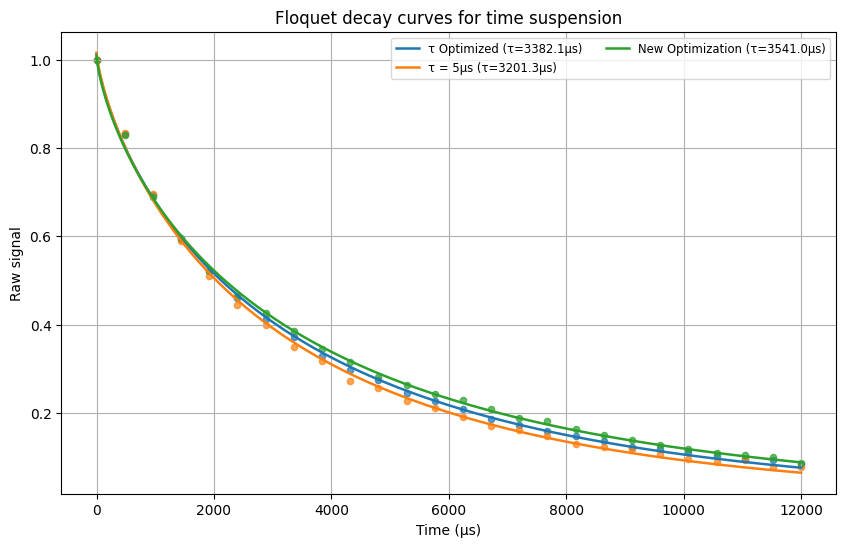

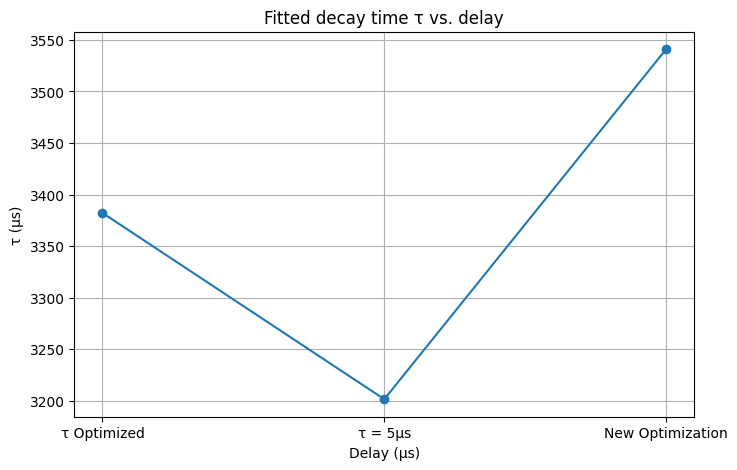

In [30]:
# case = ("Old Optimized", "τ = 15μs"); experiment_ids = (46, 45); t0 = 15
# case = ("Old Optimized", "τ = 15μs", "New Optimized"); experiment_ids = (57, 58, 56); t0 = 15
# case = ("Old Optimized", "τ = 15μs", "New Optimized", "Mason Optimized"); experiment_ids = (57, 74, 56, 73); t0 = 15
# case = ("Old Optimized", "τ = 10μs"); experiment_ids = (42,37); t0 = 10
# case = ("Old Optimized", "τ = 10μs", "Boxing Slack Optimized", "Mason Optimized"); experiment_ids = (54,53,55,72); t0 = 10
case = ("τ Optimized", "τ = 5μs", "New Optimization"); experiment_ids = (48, 47, 49); t0 = 5

if len(case) != len(experiment_ids):
    raise ValueError("Delay array and experiment IDs length mismatch")

def stretched_exps(x, A, tau, beta, tau2, beta2):
    return A* np.exp(-(x / tau) ** beta) + (1-A) * np.exp(-(x / tau2) ** beta2)

def stretched_exp(x, A, tau, beta):
    return A* np.exp(-(x / tau) ** beta)

all_taus = []
all_cases = []

fig, ax = plt.subplots(figsize=(10, 6))

for thiscase, exp_id in zip(case, experiment_ids):
    data_path = settings.save_dir / f"experiment_{exp_id:04d}/data.json"
    if not data_path.exists():
        print(f"Warning: missing {data_path}, skipping")
        continue

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0]/re[0,0]

    time = periods * (24 * t0)
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {exp_id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.3], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt
    # popt, _ = curve_fit(stretched_exps, x, y, p0=[1.0, 1000, 1.3, 1000, .7], maxfev=10000)
    all_taus.append(tau_fit)
    all_cases.append(thiscase)

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, *popt)
    # y_fit = stretched_exps(x_fit, *popt)

    ax.scatter(time, signal, s=20, alpha=0.7)
    # ax.errorbar(time, signal, yerr=(70/re[0,0]), fmt='o')
    ax.plot(x_fit, y_fit, linewidth=1.8,
            label=f"{thiscase} (τ={tau_fit:.1f}μs)")
    print(*popt)


ax.set_title("Floquet decay curves for time suspension")
ax.set_xlabel("Time (μs)")
ax.set_ylabel("Raw signal")
ax.legend(loc="upper right", fontsize="small", ncol=2)
ax.grid(True)

fig_tau, ax_tau = plt.subplots(figsize=(8, 5))
ax_tau.plot(all_cases, all_taus, marker="o", linestyle="-", color="tab:blue")
ax_tau.set_title("Fitted decay time τ vs. delay")
ax_tau.set_xlabel("Delay (μs)")
ax_tau.set_ylabel("τ (μs)")
ax_tau.grid(True)

print("Completed fitting experiments:")
for case, tau in zip(all_cases, all_taus):
    print(f"case={case} -> tau={tau:.3f}μs")

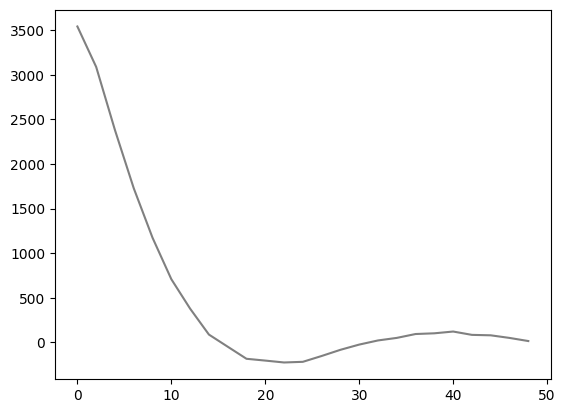

In [100]:
data_path = settings.save_dir / "wei16/experiment_0034/data.json"
with open(data_path, "r") as f: data_dict = json.load(f)
re = np.array(data_dict["I_data"], dtype=float) * 1e6
periods = np.array(data_dict["sweep_axis"], dtype=float)
c02signal = re[:, 0]
plt.plot(periods, c02signal, color='gray', label="c2=0.02")

[ 5.0000000e-02  4.0000000e-02  3.0000000e-02  2.0000000e-02
  1.0000000e-02 -6.9388939e-18 -1.0000000e-02 -2.0000000e-02
 -3.0000000e-02 -4.0000000e-02 -5.0000000e-02]


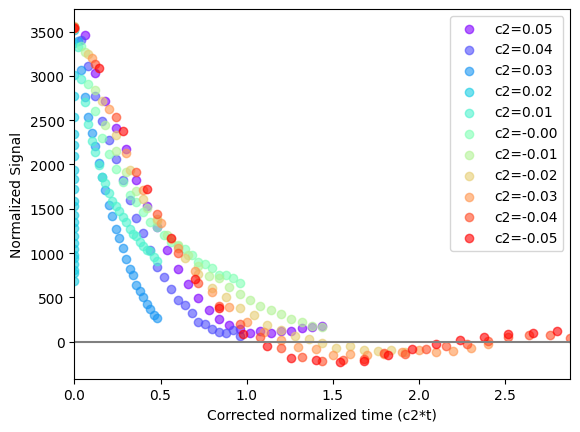

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json

# # ---- Your fit function ----
# def damped_moment(t, A, alpha, tau, b):
#     fid = A * (fid_moment_expansion(alpha * t, moments) + 1) * np.exp(-t / tau) + b
#     return np.array(fid, dtype=float)
# ---- Gaussian Sinc fit function ----
def damped_moment(t, A, b1, b2, c, d, e):
    fid = A * np.sinc((t-b1)/c) * np.exp(((t-b2)/d)**2 / 2) * np.exp(-t / e)
    return np.array(fid, dtype=float)

# ---- Experiment range ----
exp_ids = list(range(24, 35))  # 24 through 34
c2_values = -1 * np.arange(-0.05, 0.06, 0.01)  # -0.05 to 0.05
print(c2_values)

# ---- Colors (red → purple) ----
colors = plt.cm.rainbow(np.linspace(0, 1, len(exp_ids)))

plt.figure()

# ---- Loop over experiments ----
for i, exp_id in enumerate(exp_ids):
    data_path = settings.save_dir / f"wei16/experiment_{exp_id:04d}/data.json"

    with open(data_path, "r") as f:
        data_dict = json.load(f)

    re = np.array(data_dict["I_data"], dtype=float) * 1e6
    periods = np.array(data_dict["sweep_axis"], dtype=float)
    signal = re[:, 0]

    # ---- Fit curve ----
    # x_fit = np.linspace(min(periods), max(periods), 500)

    # ---- Plot ----
    label = f"c2={c2_values[i]:.2f}"
    plt.scatter(abs(c2_values[i]-.02) * periods, signal, color=colors[i], alpha=0.6, label=label)
    # plt.plot(x_fit, y_fit, color=colors[i], label=label)

    # print(f"Exp {exp_id} | c2={abs(c2_values[i]):.2f} | "
        #   f"A={popt[0]:.3f}, b1={popt[1]:.3f}, b2={popt[2]:.3f}, c={popt[3]:.3f}, d={popt[4]:.3f}, e={popt[5]:.3f}")

# ---- Final plot formatting ----
plt.plot(periods, np.zeros_like(periods), color='gray')  # baseline
plt.legend()
plt.xlim(0, max(0.06*periods))
plt.xlabel("Corrected normalized time (c2*t)")
plt.ylabel("Normalized Signal")

plt.show()